# OTF Scan — Data Load

Load OTF scan dumps from `data/lab04/streaming/scan_r*_c*/`,
apply fftshift, mask DC/RFI, frequency-switch, and build a
gridded HI map in galactic coordinates.

In [1]:
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

## 1. Load all scan dumps

In [2]:
DATA_DIR = Path('../../../data/lab04/streaming')
scan_dirs = sorted(DATA_DIR.glob('scan_r*_c*'))
print(f'{len(scan_dirs)} cells found')

# Collect all dumps
records = []
for d in scan_dirs:
    for p in sorted(d.glob('*.npz')):
        if p.name.endswith(':Zone.Identifier'):
            continue
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Parse row/col from target name
import re
for r in records:
    m = re.match(r'scan_r(\d+)_c(\d+)', r['target'])
    if m:
        r['row'] = int(m.group(1))
        r['col'] = int(m.group(2))
    else:
        r['row'] = -1
        r['col'] = -1

rows = sorted(set(r['row'] for r in records if r['row'] >= 0))
cols = sorted(set(r['col'] for r in records if r['col'] >= 0))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

print(f'Grid: {len(rows)} rows x {len(cols)} cols')
print(f'Cal: {n_cal}, Science: {n_sci}')
print(f'LO frequencies: {lo_unique} MHz')

153 cells found
1225 total dumps loaded
Grid: 9 rows x 17 cols
Cal: 4, Science: 1221
LO frequencies: [1420.0, 1421.0] MHz


## 2. fftshift + mask DC + RFI flagging

In [3]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

MASK_SKY_MHZ = 1420.0

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])

    # Mask DC bin
    r['corr00'][DC_BIN] = np.nan
    r['corr11'][DC_BIN] = np.nan

    # Mask 1420.0 MHz + 3 bins below
    bb_target = MASK_SKY_MHZ - r['lo_mhz']
    ch_center = np.argmin(np.abs(f_bb_mhz - bb_target))
    for ch in [ch_center - 3, ch_center - 2, ch_center - 1, ch_center]:
        if 0 <= ch < NFFT and ch != DC_BIN:
            r['corr00'][ch] = np.nan
            r['corr11'][ch] = np.nan

    r['stokes_I'] = r['corr00'] + r['corr11']

# RFI flagging
from scipy.ndimage import median_filter

RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = 0

for r in records:
    spec = r['stokes_I']
    local_med = median_filter(spec, size=RFI_WINDOW)
    resid = spec - local_med
    mad = np.nanmedian(np.abs(resid))
    sigma = mad / 0.6745
    bad = resid > RFI_SIGMA * sigma
    n_bad = np.sum(bad)
    if n_bad > 0:
        r['stokes_I'][bad] = np.nan
        n_flagged += n_bad

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz')
print(f'Masked DC bin: channel {DC_BIN}')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz
Masked DC bin: channel 512
RFI flagged: 78738 samples across 1225 dumps


## 3. Frequency-switched profiles per cell

For each cell, pair dumps at the two LO frequencies and compute
`R = (I1 - I2) / I2`.

In [4]:
EDGE_TRIM_MHZ = 0.256

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity: [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')

# Compute R per cell
cell_results = {}
for row in rows:
    for col in cols:
        sci_dumps = [r for r in records
                     if r['row'] == row and r['col'] == col and not r['noise_on']]
        d1 = [r['stokes_I'] for r in sci_dumps if r['lo_mhz'] == lo1]
        d2 = [r['stokes_I'] for r in sci_dumps if r['lo_mhz'] == lo2]
        n_p = min(len(d1), len(d2))
        if n_p == 0:
            continue

        I1 = np.array(d1[:n_p])
        I2 = np.array(d2[:n_p])
        R = (I1 - I2) / I2
        R_mean = np.nanmean(R, axis=0)

        # Mean pointing
        mean_alt = np.mean([r['alt'] for r in sci_dumps])
        mean_az = np.mean([r['az'] for r in sci_dumps])
        mean_ra = np.mean([r['ra'] for r in sci_dumps])
        mean_dec = np.mean([r['dec'] for r in sci_dumps])

        cell_results[(row, col)] = {
            'R_mean': R_mean,
            'R_overlap': R_mean[overlap_mask],
            'n_pairs': n_p,
            'alt': mean_alt, 'az': mean_az,
            'ra': mean_ra, 'dec': mean_dec,
        }

print(f'\n{len(cell_results)} cells with data')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity: [-130, 90] km/s

153 cells with data


/tmp/ipykernel_848875/1078917561.py:31: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R, axis=0)


## 4. HI map

Integrated R over the velocity range as a function of grid position.

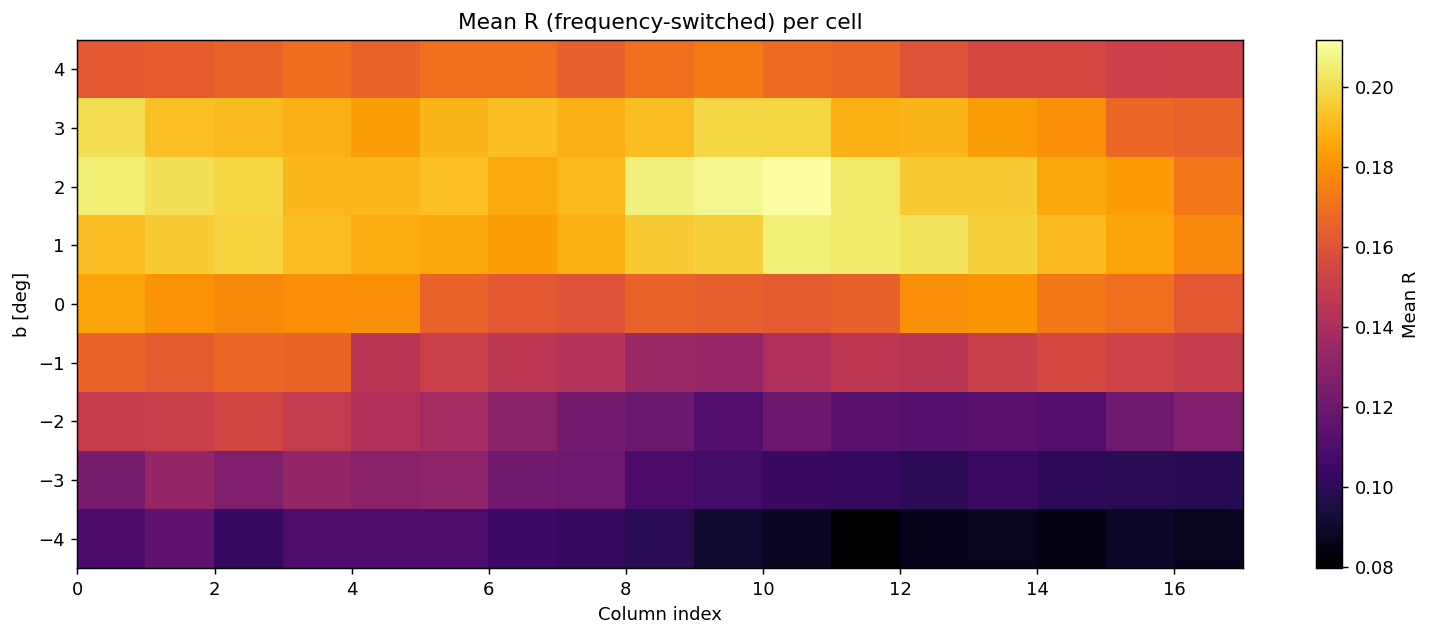

Map shape: (9, 17)
Valid cells: 153


In [5]:
# Galactic coordinates from the observe_otf.py grid
# Reconstruct l, b from the script's grid parameters
L_CENTER, B_CENTER = 90.0, 0.0
L_EXTENT, B_EXTENT = 17, 9

# The observe_otf script uses iso-HA slant; reconstruct from the grid
b_vals = [int(B_CENTER + (i - (B_EXTENT-1)/2)) for i in range(B_EXTENT)]

# We need to figure out the l values per row from the actual data
# For now, use row/col indices to build the map
map_R = np.full((B_EXTENT, L_EXTENT), np.nan)

for (row, col), cr in cell_results.items():
    if row < B_EXTENT and col < L_EXTENT:
        # Integrated R: sum over overlap channels
        map_R[row, col] = np.nanmean(cr['R_overlap'])

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(map_R, origin='lower', aspect='auto',
               extent=[0, L_EXTENT, b_vals[0] - 0.5, b_vals[-1] + 0.5],
               cmap='inferno')
ax.set_xlabel('Column index')
ax.set_ylabel('b [deg]')
ax.set_title('Mean R (frequency-switched) per cell')
plt.colorbar(im, ax=ax, label='Mean R')
fig.tight_layout()
plt.show()

print(f'Map shape: {map_R.shape}')
print(f'Valid cells: {np.sum(np.isfinite(map_R))}')

## 5. Sample spectra

Show frequency-switched profiles for a few cells along the galactic plane (b=0).

/tmp/ipykernel_848875/2148383325.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


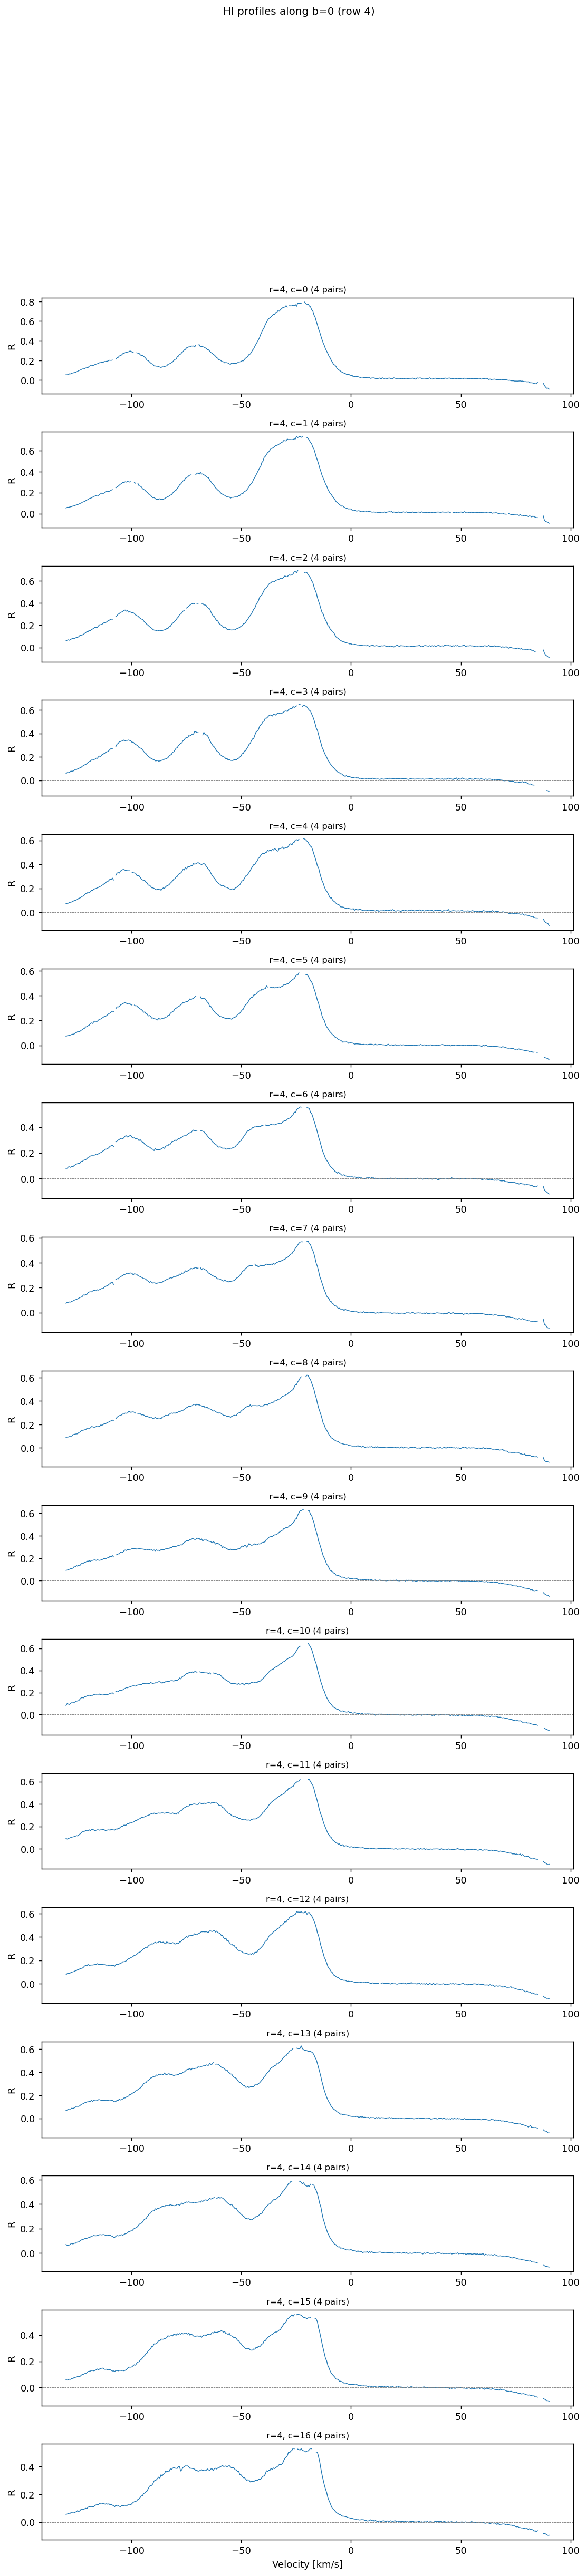

In [6]:
# Plot R vs velocity for the middle row (b=0)
mid_row = B_EXTENT // 2
cols_to_plot = [c for c in range(L_EXTENT) if (mid_row, c) in cell_results]

fig, axes = plt.subplots(len(cols_to_plot), 1,
                         figsize=(10, 2.5 * len(cols_to_plot)),
                         gridspec_kw={'hspace': 0.4})
if len(cols_to_plot) == 1:
    axes = [axes]

for i, col in enumerate(cols_to_plot):
    cr = cell_results[(mid_row, col)]
    ax = axes[i]
    ax.plot(v_overlap, cr['R_overlap'], lw=0.8, color='C0')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_ylabel('R')
    ax.set_title(f'r={mid_row}, c={col} ({cr["n_pairs"]} pairs)', fontsize=9)

axes[-1].set_xlabel('Velocity [km/s]')
fig.suptitle(f'HI profiles along b=0 (row {mid_row})', fontsize=11)
fig.tight_layout()
plt.show()

## 6. Summary

In [7]:
all_times = [r['time'] for r in records]
t0 = dt.datetime.fromtimestamp(min(all_times), tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(max(all_times), tz=dt.UTC)
wall = max(all_times) - min(all_times)

print(f'Scan grid:  {len(rows)} x {len(cols)} = {len(cell_results)} cells with data')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({n_cal} cal + {n_sci} science)')
print(f'Channels:   {NFFT} (dnu={df_khz:.2f} kHz)')

Scan grid:  9 x 17 = 153 cells with data
LO freqs:   [1420.0, 1421.0] MHz
Start:      2026-04-16 09:57:55 UTC
End:        2026-04-16 19:59:29 UTC
Duration:   601.6 min
Dumps:      1225 (4 cal + 1221 science)
Channels:   1024 (dnu=2.50 kHz)
